In [1]:
import multiprocessing
import random
import time
import math

In [3]:
def monte_carlo_chunk(chunk_size):
    """Menghitung titik dalam lingkaran untuk sejumlah sampel"""
    inside = 0
    for _ in range(chunk_size):
            x = random.uniform(-1, 1)
            y = random.uniform(-1, 1)
            if x**2 + y**2 <= 1:
                inside += 1
    return inside

In [4]:
def calculate_pi_parallel(num_samples, num_processes):
    """Menghitung π menggunakan multiprocessing"""
    chunk_size = num_samples // num_processes
    
    # Buat pool worker
    with multiprocessing.Pool(processes=num_processes) as pool:
        results = pool.map(monte_carlo_chunk, [chunk_size] * num_processes)
    
    total_inside = sum(results)
    pi_estimate = 4 * total_inside / (chunk_size * num_processes)
    return pi_estimate

In [5]:
# Testing dengan berbagai jumlah proses
if __name__ == "__main__":
    num_samples = 10_000_000
    
    for num_procs in [1, 2, 4, 8, 16, 32]:
        start_time = time.time()
        pi_est = calculate_pi_parallel(num_samples, num_procs)
        end_time = time.time()
        
        print(f"\nProses: {num_procs}")
        print(f"  Estimasi π: {pi_est}")
        print(f"  Waktu: {end_time - start_time:.4f} detik")


Proses: 1
  Estimasi π: 3.141868
  Waktu: 3.1864 detik

Proses: 2
  Estimasi π: 3.1414548
  Waktu: 1.6260 detik

Proses: 4
  Estimasi π: 3.141662
  Waktu: 1.2070 detik

Proses: 8
  Estimasi π: 3.1415824
  Waktu: 0.9522 detik

Proses: 16
  Estimasi π: 3.1412912
  Waktu: 0.7954 detik

Proses: 32
  Estimasi π: 3.1421036
  Waktu: 0.8581 detik


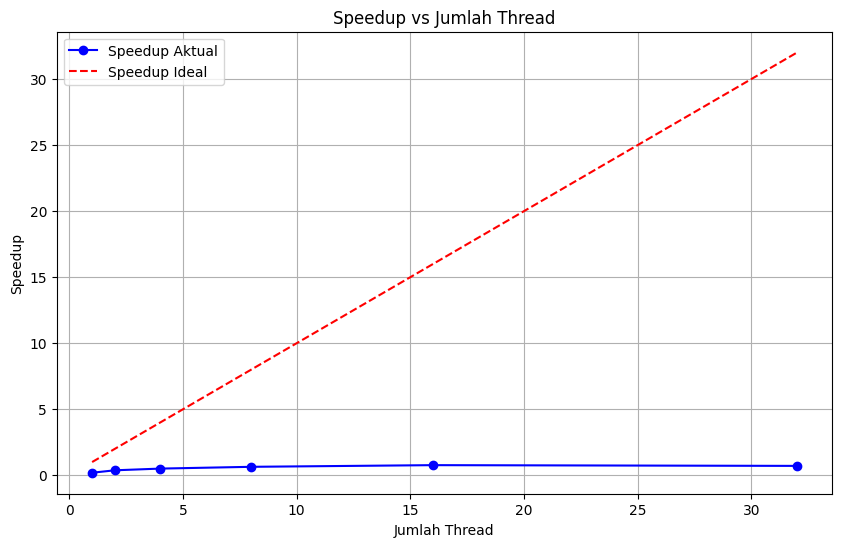

In [1]:
import matplotlib.pyplot as plt

# Data contoh
thread_counts = [1, 2, 4, 8, 16, 32]
speedups = [0.1908, 0.3739, 0.5036, 0.6384, 0.7643, 0.7084]

plt.figure(figsize=(10, 6))
plt.plot(thread_counts, speedups, 'bo-', label='Speedup Aktual')
plt.plot(thread_counts, thread_counts, 'r--', label='Speedup Ideal')
plt.xlabel('Jumlah Thread')
plt.ylabel('Speedup')
plt.title('Speedup vs Jumlah Thread')
plt.legend()
plt.grid(True)
plt.savefig('speedup_analysis.png')
plt.show()
